# Thin-Limit Flux-Volume Check

This notebook recomputes the thin-limit expected 4PI-monitor intensity from

`I_exp = flux * n_V * V_sample * sigma_inc,V * DeltaOmega / (4*pi)`

The flux is estimated from the central 2 cm by 1 cm area of `flux_scan/sample_flux_in_sample.dat`. That same flux estimate is applied to every thickness run.

In [139]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import chi2

run_root = Path('HST')
if not run_root.exists():
    run_root = Path('geometry_optimization/PSI_instrument/thinlimit/HST')
flux_run_dir = Path('flux_scan')
if not flux_run_dir.exists():
    flux_run_dir = Path('geometry_optimization/PSI_instrument/thinlimit/flux_scan')

# User-specified vanadium number density. Interpreting "7.223e2e" as 7.223e22.
vanadium_number_density_cm3 = 7.223e22
sigma_inc_vanadium_barn = 5.08
sigma_inc_vanadium_cm2 = sigma_inc_vanadium_barn * 1e-24

include_lids = True
lid_thickness_percent_of_wall = 100.0

flux_monitor_name = 'sample_flux_in_sample'
flux_area_width_cm = 2.0
flux_area_height_cm = 1.0
spherical_monitor_names = (
    'sample_spherical_monitor_scattered',
    'asymmetry_4PI_test',
    'sample_spherical_monitor',
)

latitude_halfwidth_deg = 2.0
pole_cut_deg = 30.0
apply_cosine_correction = True
cosine_floor = 1e-6
window_center_deg = 75.0
window_width_deg = 60.0

# Fit settings for observed/expected ratio vs wall thickness.
cm_to_mm = 10.0
thin_linear_fit_max_mm = 0.01

print(run_root.resolve())
print(flux_run_dir.resolve())

/Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/thinlimit/HST
/Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/thinlimit/flux_scan


In [140]:
def parse_mccode_params(sim_file):
    params = {}
    pattern = re.compile(r'^\s*#?\s*Param:\s*([A-Za-z0-9_]+)=(.+?)\s*$')
    with Path(sim_file).open('r') as f:
        for line in f:
            match = pattern.match(line)
            if match:
                try:
                    params[match.group(1)] = float(match.group(2))
                except ValueError:
                    pass
    return params


def _parse_float_tuple(line, n):
    return tuple(float(value) for value in line.split(':', 1)[1].split()[:n])


def parse_mccode_dat(path):
    path = Path(path)
    lines = path.read_text(errors='ignore').splitlines()
    meta = {'path': path}
    monitor_type = ''
    nx = ny = None

    for line in lines:
        if line.startswith('# type:'):
            monitor_type = line.split(':', 1)[1].strip()
            dim_match = re.search(r'array_(1d|2d)\(([^)]*)\)', monitor_type)
            if dim_match:
                dims = [int(value.strip()) for value in dim_match.group(2).split(',') if value.strip()]
                nx = dims[0] if dims else None
                ny = dims[1] if len(dims) > 1 else None
        elif line.startswith('# component:'):
            meta['component'] = line.split(':', 1)[1].strip()
        elif line.startswith('# xlimits:'):
            meta['xlimits'] = _parse_float_tuple(line, 2)
        elif line.startswith('# xylimits:'):
            meta['xylimits'] = _parse_float_tuple(line, 4)
        elif line.startswith('# values:'):
            values = [float(value) for value in line.split(':', 1)[1].split()[:3]]
            meta['header_total'] = values[0]
            meta['header_error'] = values[1] if len(values) > 1 else np.nan
            meta['header_counts'] = values[2] if len(values) > 2 else np.nan

    data_start = None
    for index, line in enumerate(lines):
        if line.startswith('# Data') and line.rstrip().endswith('I:'):
            data_start = index + 1
            break
    if data_start is None:
        raise ValueError(f'Could not find intensity section in {path}')

    rows = []
    for line in lines[data_start:]:
        stripped = line.strip()
        if stripped and not stripped.startswith('#'):
            rows.append([float(value) for value in stripped.split()])
    data = np.asarray(rows, dtype=float)

    if monitor_type.startswith('array_1d'):
        x = data[:, 0] if data.ndim == 2 and data.shape[1] >= 2 else np.arange(data.size)
        intensity = data[:, 1] if data.ndim == 2 and data.shape[1] >= 2 else data.reshape(-1)
        meta.update({'kind': '1d', 'x': x, 'I': intensity, 'I_err': None, 'total': float(np.nansum(intensity))})
        return meta

    intensity = data[:ny, :] if ny is not None and data.shape[0] >= ny else data
    error = data[ny:2 * ny, :] if ny is not None and data.shape[0] >= 2 * ny else None
    counts = data[2 * ny:3 * ny, :] if ny is not None and data.shape[0] >= 3 * ny else None
    meta.update({'kind': '2d', 'I': intensity, 'I_err': error, 'N': counts, 'total': float(np.nansum(intensity))})
    return meta


def load_records(run_dir):
    records = {}
    for dat_file in Path(run_dir).glob('*.dat'):
        record = parse_mccode_dat(dat_file)
        records[dat_file.stem] = record
        if record.get('component'):
            records[record['component']] = record
    return records


def first_available_record(records, names):
    for name in names:
        if name in records:
            return records[name]
    raise KeyError(f'None of these records were found: {names}')


def record_total(record):
    return float(record.get('header_total', record['total']))


def record_total_error(record):
    if np.isfinite(record.get('header_error', np.nan)):
        return float(record['header_error'])
    if record.get('I_err') is not None:
        return float(np.sqrt(np.nansum(np.asarray(record['I_err'], dtype=float) ** 2)))
    return np.nan


def coordinate_centers(record):
    x_min, x_max, y_min, y_max = record['xylimits']
    n_y, n_x = record['I'].shape
    x_edges = np.linspace(x_min, x_max, n_x + 1)
    y_edges = np.linspace(y_min, y_max, n_y + 1)
    return 0.5 * (x_edges[:-1] + x_edges[1:]), 0.5 * (y_edges[:-1] + y_edges[1:]), x_edges, y_edges

In [141]:
def geometry_from_sim_cm(run_dir):
    params = parse_mccode_params(Path(run_dir) / 'mccode.sim')
    required = ('sampleRadius', 'sampleHeight', 'sampleThickness')
    missing = [key for key in required if key not in params]
    if missing:
        raise ValueError(f'Missing {missing} in {Path(run_dir) / "mccode.sim"}')
    return {
        'outer_radius_cm': params['sampleRadius'] * 100.0,
        'outer_height_cm': params['sampleHeight'] * 100.0,
        'wall_thickness_cm': params['sampleThickness'] * 100.0,
    }


def lid_thickness_cm(geometry):
    return geometry['wall_thickness_cm'] * lid_thickness_percent_of_wall / 100.0 if include_lids else 0.0


def sample_material_volume_cm3(geometry):
    R = geometry['outer_radius_cm']
    H = geometry['outer_height_cm']
    t_wall = geometry['wall_thickness_cm']
    t_lid = lid_thickness_cm(geometry)
    r = max(R - t_wall, 0.0)
    H_inner = max(H - 2.0 * t_lid, 0.0)
    if include_lids:
        return np.pi * R**2 * H - np.pi * r**2 * H_inner
    return np.pi * (R**2 - r**2) * H


def flux_from_sample_flux_monitor(records):
    record = first_available_record(records, (flux_monitor_name,))
    x_centers, y_centers, _, _ = coordinate_centers(record)
    x_halfwidth = 0.5 * flux_area_width_cm
    y_halfheight = 0.5 * flux_area_height_cm
    x_mask = (x_centers >= -x_halfwidth) & (x_centers <= x_halfwidth)
    y_mask = (y_centers >= -y_halfheight) & (y_centers <= y_halfheight)
    if not np.any(x_mask) or not np.any(y_mask):
        raise ValueError(f'No bins selected for {flux_area_width_cm:g} cm by {flux_area_height_cm:g} cm flux area')

    selection = np.outer(y_mask, x_mask)
    area_cm2 = flux_area_width_cm * flux_area_height_cm
    intensity = float(np.nansum(np.asarray(record['I'], dtype=float)[selection]))
    if record.get('I_err') is None:
        intensity_error = np.nan
    else:
        intensity_error = float(np.sqrt(np.nansum(np.asarray(record['I_err'], dtype=float)[selection] ** 2)))
    return {
        'monitor': record['path'].name,
        'area_cm2': area_cm2,
        'area_mm2': area_cm2 * cm_to_mm ** 2,
        'area_width_cm': flux_area_width_cm,
        'area_height_cm': flux_area_height_cm,
        'area_width_mm': flux_area_width_cm * cm_to_mm,
        'area_height_mm': flux_area_height_cm * cm_to_mm,
        'selected_x_bins': int(np.count_nonzero(x_mask)),
        'selected_y_bins': int(np.count_nonzero(y_mask)),
        'intensity': intensity,
        'intensity_error': intensity_error,
        'flux_cm2_s': intensity / area_cm2,
        'flux_error_cm2_s': intensity_error / area_cm2 if np.isfinite(intensity_error) else np.nan,
    }


def valid_latitude_mask(record):
    _, lat_centers, _, _ = coordinate_centers(record)
    return np.abs(lat_centers) <= 90.0 - pole_cut_deg


def latitude_mask(record):
    _, lat_centers, _, _ = coordinate_centers(record)
    return (np.abs(lat_centers) <= latitude_halfwidth_deg) & valid_latitude_mask(record)


def corrected_band_solid_angle_per_longitude_sr(record, lat_mask):
    x_min, x_max, y_min, y_max = record['xylimits']
    n_lat, n_lon = record['I'].shape
    dlon = np.deg2rad((x_max - x_min) / n_lon)
    lat_edges = np.linspace(y_min, y_max, n_lat + 1)
    lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])

    omega = 0.0
    for i, use_bin in enumerate(lat_mask):
        if not use_bin:
            continue
        lat1 = np.deg2rad(lat_edges[i])
        lat2 = np.deg2rad(lat_edges[i + 1])
        domega = dlon * (np.sin(lat2) - np.sin(lat1))
        if apply_cosine_correction:
            cos_lat = np.cos(np.deg2rad(lat_centers[i]))
            if abs(cos_lat) < cosine_floor:
                continue
            domega /= cos_lat
        omega += domega
    return float(omega)


def corrected_window_solid_angle_from_masks_sr(record, lat_mask, lon_mask):
    x_min, x_max, y_min, y_max = record['xylimits']
    n_lat, n_lon = record['I'].shape
    lon_edges = np.linspace(x_min, x_max, n_lon + 1)
    lat_edges = np.linspace(y_min, y_max, n_lat + 1)
    lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])
    dlon = np.deg2rad((x_max - x_min) / n_lon)

    omega = 0.0
    for i, use_lat in enumerate(lat_mask):
        if not use_lat:
            continue
        lat_factor = np.sin(np.deg2rad(lat_edges[i + 1])) - np.sin(np.deg2rad(lat_edges[i]))
        if apply_cosine_correction:
            cos_lat = np.cos(np.deg2rad(lat_centers[i]))
            if abs(cos_lat) < cosine_floor:
                continue
            lat_factor /= cos_lat
        omega += np.count_nonzero(lon_mask) * dlon * lat_factor
    return float(omega)


def angular_delta_deg(values, center):
    return (values - center + 180.0) % 360.0 - 180.0


def symmetric_window_mask(longitude):
    half_width = window_width_deg / 2.0
    positive = np.abs(angular_delta_deg(longitude, window_center_deg)) <= half_width
    negative = np.abs(angular_delta_deg(longitude, -window_center_deg)) <= half_width
    return positive | negative


def observed_latitude_band_profile(record, lat_mask):
    lon_centers, lat_centers, _, _ = coordinate_centers(record)
    image = np.asarray(record['I'], dtype=float).copy()
    error = None if record.get('I_err') is None else np.asarray(record['I_err'], dtype=float).copy()

    if apply_cosine_correction:
        cos_lat = np.cos(np.deg2rad(lat_centers))
        valid = np.abs(cos_lat) >= cosine_floor
        image[valid, :] /= cos_lat[valid, None]
        image[~valid, :] = np.nan
        if error is not None:
            error[valid, :] /= cos_lat[valid, None]
            error[~valid, :] = np.nan

    profile = np.nansum(image[lat_mask, :], axis=0)
    if error is None:
        profile_error = None
    else:
        profile_error = np.sqrt(np.nansum(error[lat_mask, :] ** 2, axis=0))
    return lon_centers, profile, profile_error

In [142]:
def expected_and_observed_for_run(run_dir, flux):
    records = load_records(run_dir)
    spherical = first_available_record(records, spherical_monitor_names)
    geometry = geometry_from_sim_cm(run_dir)
    volume_cm3 = sample_material_volume_cm3(geometry)

    lat_mask = latitude_mask(spherical)
    delta_omega_per_lon_bin = corrected_band_solid_angle_per_longitude_sr(spherical, lat_mask)
    longitude, profile, profile_error = observed_latitude_band_profile(spherical, lat_mask)
    lon_mask = symmetric_window_mask(longitude)
    n_window_bins = int(np.count_nonzero(lon_mask))
    delta_omega_window = corrected_window_solid_angle_from_masks_sr(spherical, lat_mask, lon_mask)
    expected_per_lon_bin = (
        flux['flux_cm2_s']
        * vanadium_number_density_cm3
        * volume_cm3
        * sigma_inc_vanadium_cm2
        * delta_omega_per_lon_bin
        / (4.0 * np.pi)
    )
    expected_per_lon_bin_err = (
        expected_per_lon_bin * flux['flux_error_cm2_s'] / flux['flux_cm2_s']
        if flux['flux_cm2_s'] > 0 and np.isfinite(flux['flux_error_cm2_s'])
        else np.nan
    )
    expected_window_sum = expected_per_lon_bin * n_window_bins
    expected_window_sum_err = (
        expected_window_sum * flux['flux_error_cm2_s'] / flux['flux_cm2_s']
        if flux['flux_cm2_s'] > 0 and np.isfinite(flux['flux_error_cm2_s'])
        else np.nan
    )
    observed_window_sum = float(np.nansum(profile[lon_mask]))
    observed_window_sum_err = np.nan
    if profile_error is not None:
        observed_window_sum_err = float(np.sqrt(np.nansum(profile_error[lon_mask] ** 2)))

    observed_over_expected = observed_window_sum / expected_window_sum if expected_window_sum > 0 else np.nan
    observed_over_expected_err = np.nan
    if observed_window_sum > 0 and expected_window_sum > 0 and np.isfinite(observed_window_sum_err) and np.isfinite(expected_window_sum_err):
        observed_over_expected_err = observed_over_expected * np.sqrt(
            (observed_window_sum_err / observed_window_sum) ** 2
            + (expected_window_sum_err / expected_window_sum) ** 2
        )

    run_dir = Path(run_dir)
    return {
        'run': run_dir.name,
        'run_dir': str(run_dir),
        'spherical_monitor': spherical['path'].name,
        'flux_run_dir': str(flux['run_dir']),
        'flux_monitor': flux['monitor'],
        'radius_cm': geometry['outer_radius_cm'],
        'height_cm': geometry['outer_height_cm'],
        'thickness_cm': geometry['wall_thickness_cm'],
        'radius_mm': geometry['outer_radius_cm'] * cm_to_mm,
        'height_mm': geometry['outer_height_cm'] * cm_to_mm,
        'thickness_mm': geometry['wall_thickness_cm'] * cm_to_mm,
        'volume_cm3': volume_cm3,
        'N_sample': vanadium_number_density_cm3 * volume_cm3,
        'flux_area_cm2': flux['area_cm2'],
        'flux_area_mm2': flux['area_mm2'],
        'flux_intensity': flux['intensity'],
        'flux_intensity_err': flux['intensity_error'],
        'flux_cm2_s': flux['flux_cm2_s'],
        'flux_err_cm2_s': flux['flux_error_cm2_s'],
        'delta_omega_per_lon_bin_sr': delta_omega_per_lon_bin,
        'delta_omega_window_sr': delta_omega_window,
        'n_window_bins': n_window_bins,
        'expected_per_lon_bin': expected_per_lon_bin,
        'expected_per_lon_bin_err': expected_per_lon_bin_err,
        'expected_window_sum': expected_window_sum,
        'expected_window_sum_err': expected_window_sum_err,
        'observed_window_sum': observed_window_sum,
        'observed_window_sum_err': observed_window_sum_err,
        'observed_over_expected': observed_over_expected,
        'observed_over_expected_err': observed_over_expected_err,
    }


def discover_run_dirs(root):
    root = Path(root)
    run_dirs = sorted({path.parent for path in root.rglob('mccode.sim')})
    return sorted(run_dirs, key=lambda path: (geometry_from_sim_cm(path)['wall_thickness_cm'], str(path)))


flux_records = load_records(flux_run_dir)
flux = flux_from_sample_flux_monitor(flux_records)
flux['run_dir'] = Path(flux_run_dir)

rows = []
for run_dir in discover_run_dirs(run_root):
    try:
        rows.append(expected_and_observed_for_run(run_dir, flux))
    except Exception as exc:
        print(f'Skipping {run_dir}: {exc}')

results = pd.DataFrame(rows).sort_values('thickness_cm').reset_index(drop=True)
if results.empty:
    raise ValueError(f'No usable runs found under {run_root.resolve()}')

display_cols = [
    'run',
    'run_dir',
    'spherical_monitor',
    'flux_run_dir',
    'flux_monitor',
    'radius_mm',
    'height_mm',
    'thickness_mm',
    'volume_cm3',
    'N_sample',
    'flux_area_mm2',
    'flux_area_cm2',
    'flux_cm2_s',
    'flux_err_cm2_s',
    'delta_omega_per_lon_bin_sr',
    'delta_omega_window_sr',
    'n_window_bins',
    'expected_window_sum',
    'expected_window_sum_err',
    'observed_window_sum',
    'observed_window_sum_err',
    'observed_over_expected',
    'observed_over_expected_err',
]
display(results[display_cols])

print(f'Run root: {run_root.resolve()}')
print(f'Runs: {len(results)}')
print(f'Flux run: {Path(flux["run_dir"]).resolve()}')
print(f'Flux monitor: {flux_monitor_name}')
print(f'Flux = {flux["flux_cm2_s"]:.6g} +/- {flux["flux_error_cm2_s"]:.6g} n/(s cm^2)')
print(f'Flux integration area: {flux["area_width_mm"]:.6g} mm by {flux["area_height_mm"]:.6g} mm = {flux["area_mm2"]:.6g} mm^2 ({flux["area_cm2"]:.6g} cm^2 for flux units)')
print(f'Selected flux bins: {flux["selected_x_bins"]} x {flux["selected_y_bins"]}')
print(f'n_V: {vanadium_number_density_cm3:.6g} cm^-3')
print(f'sigma_inc,V: {sigma_inc_vanadium_cm2:.6g} cm^2 ({sigma_inc_vanadium_barn:g} barn)')
print(f'DeltaOmega per longitude bin: {results["delta_omega_per_lon_bin_sr"].iloc[0]:.6g} sr')
print(f'DeltaOmega from selected detector bins: {results["delta_omega_window_sr"].iloc[0]:.6g} sr')
print('Expected window sum uses n_window_bins * DeltaOmega per longitude bin.')

,run,run_dir,spherical_monitor,flux_run_dir,flux_monitor,radius_mm,height_mm,thickness_mm,volume_cm3,N_sample,...,flux_err_cm2_s,delta_omega_per_lon_bin_sr,delta_omega_window_sr,n_window_bins,expected_window_sum,expected_window_sum_err,observed_window_sum,observed_window_sum_err,observed_over_expected,observed_over_expected_err
0,PSI_1e-8,HST/PSI_1e-8,sample_spherical_monitor_scattered.dat,flux_scan,sample_flux_in_sample.dat,10.0,10.0,0.00001,0.000013,9.076678e+17,...,8873.831394,0.002437,0.151083,62,0.332552,0.000492,0.351471,0.000671,1.056892,0.002553
1,PSI_1e-8_1e10n,HST/PSI_1e-8_1e10n,sample_spherical_monitor_scattered.dat,flux_scan,sample_flux_in_sample.dat,10.0,10.0,0.00001,0.000013,9.076678e+17,...,8873.831394,0.002437,0.151083,62,0.332552,0.000492,0.352973,0.000273,1.061408,0.001772
2,PSI_2e-8,HST/PSI_2e-8,sample_spherical_monitor_scattered.dat,flux_scan,sample_flux_in_sample.dat,10.0,10.0,0.00002,0.000025,1.815333e+18,...,8873.831394,0.002437,0.151083,62,0.665102,0.000984,0.690055,0.001505,1.037518,0.002734
3,PSI_5e-8,HST/PSI_5e-8,sample_spherical_monitor_scattered.dat,flux_scan,sample_flux_in_sample.dat,10.0,10.0,0.00005,0.000063,4.538316e+18,...,8873.831394,0.002437,0.151083,62,1.662750,0.002460,1.694835,0.003502,1.019296,0.002590
4,PSI_2e-7,HST/PSI_2e-7,sample_spherical_monitor_scattered.dat,flux_scan,sample_flux_in_sample.dat,10.0,10.0,0.00020,0.000251,1.815293e+19,...,8873.831394,0.002437,0.151083,62,6.650874,0.009838,6.748992,0.017154,1.014753,0.002984
5,PSI_5e-7,HST/PSI_5e-7,sample_spherical_monitor_scattered.dat,flux_scan,sample_flux_in_sample.dat,10.0,10.0,0.00050,0.000628,4.538061e+19,...,8873.831394,0.002437,0.151083,62,16.626560,0.024595,16.875306,0.038952,1.014961,0.002783
6,PSI_1e-6,HST/PSI_1e-6,sample_spherical_monitor_scattered.dat,flux_scan,sample_flux_in_sample.dat,10.0,10.0,0.00100,0.001256,9.075555e+19,...,8873.831394,0.002437,0.151083,62,33.251043,0.049187,33.293320,0.059247,1.001271,0.002317
7,PSI_2e-6,HST/PSI_2e-6,sample_spherical_monitor_scattered.dat,flux_scan,sample_flux_in_sample.dat,10.0,10.0,0.00200,0.002513,1.814884e+20,...,8873.831394,0.002437,0.151083,62,66.493772,0.098362,66.132549,0.113485,0.994568,0.002253
8,PSI_5e-6,HST/PSI_5e-6,sample_spherical_monitor_scattered.dat,flux_scan,sample_flux_in_sample.dat,10.0,10.0,0.00500,0.006279,4.535509e+20,...,8873.831394,0.002437,0.151083,62,166.172095,0.245813,162.072128,0.251165,0.975327,0.002090
9,PSI_1e-5,HST/PSI_1e-5,sample_spherical_monitor_scattered.dat,flux_scan,sample_flux_in_sample.dat,10.0,10.0,0.01000,0.012551,9.065348e+20,...,8873.831394,0.002437,0.151083,62,332.136469,0.491319,313.159519,0.436207,0.942864,0.001916


Run root: /Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/thinlimit/HST
Runs: 48
Flux run: /Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/thinlimit/flux_scan
Flux monitor: sample_flux_in_sample
Flux = 5.99879e+06 +/- 8873.83 n/(s cm^2)
Flux integration area: 20 mm by 10 mm = 200 mm^2 (2 cm^2 for flux units)
Selected flux bins: 34 x 16
n_V: 7.223e+22 cm^-3
sigma_inc,V: 5.08e-24 cm^2 (5.08 barn)
DeltaOmega per longitude bin: 0.00243682 sr
DeltaOmega from selected detector bins: 0.151083 sr
Expected window sum uses n_window_bins * DeltaOmega per longitude bin.


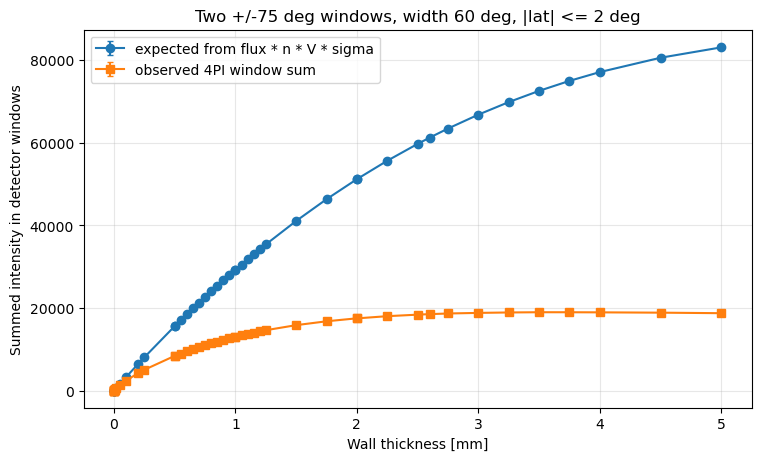

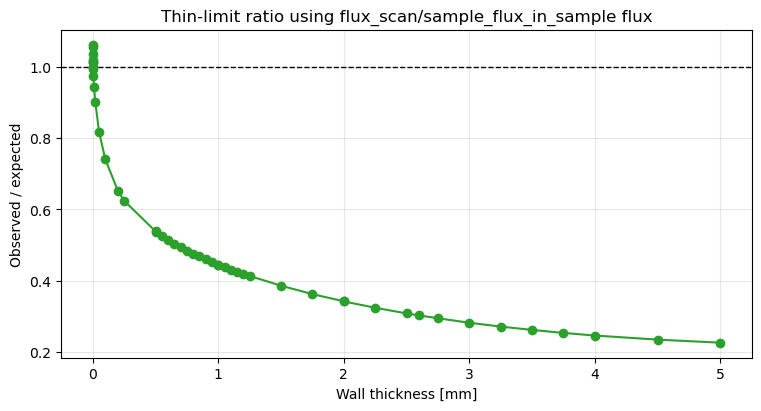

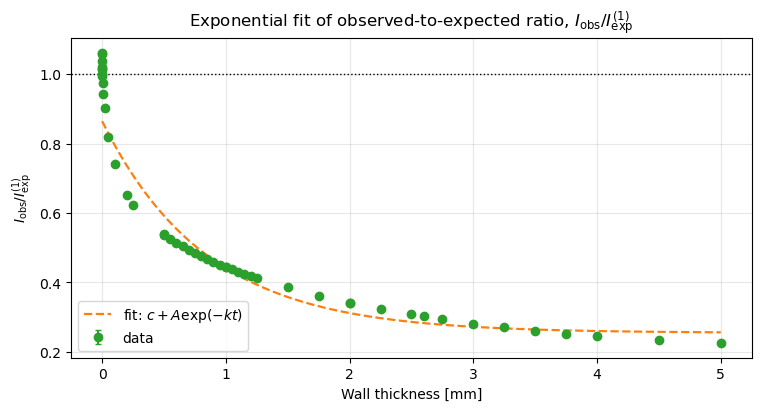

Exponential fit R(t) = c + A exp(-k t):
  c:        0.25467848
  A:        0.6099075
  k [1/mm]: 1.1842878
  R(0):     0.86458597


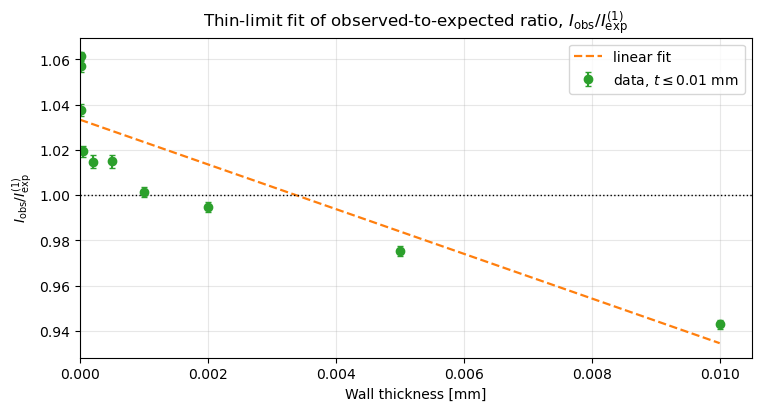

Linear fit for t <= 0.01 mm:
  slope [1/mm]: -9.8784314
  intercept:    1.0333262
  points:       10
  chi2/dof:     621.49878 / 8
  red chi2:     77.687348
  p-value:      5.5787031e-129


,run,thickness_mm,volume_cm3,N_sample,flux_area_mm2,flux_area_cm2,flux_cm2_s,flux_err_cm2_s,delta_omega_per_lon_bin_sr,delta_omega_window_sr,n_window_bins,expected_window_sum,expected_window_sum_err,observed_window_sum,observed_window_sum_err,observed_over_expected,observed_over_expected_err
0,PSI_1e-8,0.00001,0.000013,9.076678e+17,200.0,2.0,5.998793e+06,8873.831394,0.002437,0.151083,62,0.332552,0.000492,0.351471,0.000671,1.056892,0.002553
1,PSI_1e-8_1e10n,0.00001,0.000013,9.076678e+17,200.0,2.0,5.998793e+06,8873.831394,0.002437,0.151083,62,0.332552,0.000492,0.352973,0.000273,1.061408,0.001772
2,PSI_2e-8,0.00002,0.000025,1.815333e+18,200.0,2.0,5.998793e+06,8873.831394,0.002437,0.151083,62,0.665102,0.000984,0.690055,0.001505,1.037518,0.002734
3,PSI_5e-8,0.00005,0.000063,4.538316e+18,200.0,2.0,5.998793e+06,8873.831394,0.002437,0.151083,62,1.662750,0.002460,1.694835,0.003502,1.019296,0.002590
4,PSI_2e-7,0.00020,0.000251,1.815293e+19,200.0,2.0,5.998793e+06,8873.831394,0.002437,0.151083,62,6.650874,0.009838,6.748992,0.017154,1.014753,0.002984
5,PSI_5e-7,0.00050,0.000628,4.538061e+19,200.0,2.0,5.998793e+06,8873.831394,0.002437,0.151083,62,16.626560,0.024595,16.875306,0.038952,1.014961,0.002783
6,PSI_1e-6,0.00100,0.001256,9.075555e+19,200.0,2.0,5.998793e+06,8873.831394,0.002437,0.151083,62,33.251043,0.049187,33.293320,0.059247,1.001271,0.002317
7,PSI_2e-6,0.00200,0.002513,1.814884e+20,200.0,2.0,5.998793e+06,8873.831394,0.002437,0.151083,62,66.493772,0.098362,66.132549,0.113485,0.994568,0.002253
8,PSI_5e-6,0.00500,0.006279,4.535509e+20,200.0,2.0,5.998793e+06,8873.831394,0.002437,0.151083,62,166.172095,0.245813,162.072128,0.251165,0.975327,0.002090
9,PSI_1e-5,0.01000,0.012551,9.065348e+20,200.0,2.0,5.998793e+06,8873.831394,0.002437,0.151083,62,332.136469,0.491319,313.159519,0.436207,0.942864,0.001916


In [143]:
fig, ax = plt.subplots(figsize=(7.5, 4.5), constrained_layout=True)
ax.errorbar(
    results['thickness_mm'],
    results['expected_window_sum'],
    yerr=results['expected_window_sum_err'],
    fmt='o-',
    capsize=2,
    label='expected from flux * n * V * sigma',
)
ax.errorbar(
    results['thickness_mm'],
    results['observed_window_sum'],
    yerr=results['observed_window_sum_err'],
    fmt='s-',
    capsize=2,
    label='observed 4PI window sum',
)
ax.set_xlabel('Wall thickness [mm]')
ax.set_ylabel('Summed intensity in detector windows')
ax.set_title(f'Two +/-{window_center_deg:g} deg windows, width {window_width_deg:g} deg, |lat| <= {latitude_halfwidth_deg:g} deg')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.0), constrained_layout=True)
ax.errorbar(
    results['thickness_mm'],
    results['observed_over_expected'],
    yerr=results['observed_over_expected_err'],
    fmt='o-',
    capsize=2,
    color='tab:green',
)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0)
ax.set_xlabel('Wall thickness [mm]')
ax.set_ylabel('Observed / expected')
ax.set_title('Thin-limit ratio using flux_scan/sample_flux_in_sample flux')
ax.grid(alpha=0.3)
plt.show()


def exp_model(thickness_mm, c, A, k):
    return c + A * np.exp(-k * thickness_mm)


fit_x = results['thickness_mm'].to_numpy(dtype=float)
fit_y = results['observed_over_expected'].to_numpy(dtype=float)
fit_yerr = results['observed_over_expected_err'].to_numpy(dtype=float)
fit_mask = np.isfinite(fit_x) & np.isfinite(fit_y) & (fit_y > 0.0)
fit_sigma = np.where(np.isfinite(fit_yerr[fit_mask]) & (fit_yerr[fit_mask] > 0.0), fit_yerr[fit_mask], np.nan)
if np.any(~np.isfinite(fit_sigma)):
    finite_sigma = fit_sigma[np.isfinite(fit_sigma) & (fit_sigma > 0.0)]
    fallback_sigma = np.nanmedian(finite_sigma) if finite_sigma.size else 1.0
    fit_sigma = np.where(np.isfinite(fit_sigma) & (fit_sigma > 0.0), fit_sigma, fallback_sigma)

exp_fit = None
if np.count_nonzero(fit_mask) >= 4:
    x_fit = fit_x[fit_mask]
    y_fit = fit_y[fit_mask]
    p0 = [float(np.nanmin(y_fit)), float(np.nanmax(y_fit) - np.nanmin(y_fit)), 10.0 / np.nanmax(x_fit)]
    bounds = ([-np.inf, -np.inf, 0.0], [np.inf, np.inf, np.inf])
    popt, pcov = curve_fit(
        exp_model,
        x_fit,
        y_fit,
        p0=p0,
        sigma=fit_sigma,
        absolute_sigma=False,
        bounds=bounds,
        maxfev=100000,
    )
    exp_fit = {
        'c': popt[0],
        'A': popt[1],
        'k_mm_inv': popt[2],
        'R0': popt[0] + popt[1],
        'cov': pcov,
    }

fig, ax = plt.subplots(figsize=(7.5, 4.0), constrained_layout=True)
ax.errorbar(fit_x[fit_mask], fit_y[fit_mask], yerr=fit_yerr[fit_mask], fmt='o', capsize=2, color='tab:green', label='data')
if exp_fit is not None:
    fit_grid = np.linspace(np.nanmin(fit_x[fit_mask]), np.nanmax(fit_x[fit_mask]), 400)
    ax.plot(
        fit_grid,
        exp_model(fit_grid, exp_fit['c'], exp_fit['A'], exp_fit['k_mm_inv']),
        color='tab:orange',
        linestyle='--',
        linewidth=1.6,
        label=r'fit: $c + A\exp(-k t)$',
    )
ax.axhline(1.0, color='black', linestyle=':', linewidth=1.0)
ax.set_xlabel('Wall thickness [mm]')
ax.set_ylabel(r'$I_{\mathrm{obs}}/I_{\mathrm{exp}}^{(1)}$')
ax.set_title(r'Exponential fit of observed-to-expected ratio, $I_{\mathrm{obs}}/I_{\mathrm{exp}}^{(1)}$')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()

if exp_fit is not None:
    print('Exponential fit R(t) = c + A exp(-k t):')
    print(f"  c:        {exp_fit['c']:.8g}")
    print(f"  A:        {exp_fit['A']:.8g}")
    print(f"  k [1/mm]: {exp_fit['k_mm_inv']:.8g}")
    print(f"  R(0):     {exp_fit['R0']:.8g}")

thin_mask = fit_mask & (fit_x <= thin_linear_fit_max_mm)
linear_fit = None
if np.count_nonzero(thin_mask) >= 2:
    thin_x = fit_x[thin_mask]
    thin_y = fit_y[thin_mask]
    thin_yerr = fit_yerr[thin_mask]
    weights = np.where(np.isfinite(thin_yerr) & (thin_yerr > 0.0), 1.0 / thin_yerr, 1.0)
    slope, intercept = np.polyfit(thin_x, thin_y, deg=1, w=weights)
    fitted_y = slope * thin_x + intercept
    chi2_mask = np.isfinite(thin_yerr) & (thin_yerr > 0.0)
    chi2_stat = float(np.sum(((thin_y[chi2_mask] - fitted_y[chi2_mask]) / thin_yerr[chi2_mask]) ** 2)) if np.any(chi2_mask) else np.nan
    dof = int(np.count_nonzero(chi2_mask) - 2)
    red_chi2 = chi2_stat / dof if dof > 0 else np.nan
    p_value = float(chi2.sf(chi2_stat, dof)) if dof > 0 and np.isfinite(chi2_stat) else np.nan
    linear_fit = {
        'slope_mm_inv': slope,
        'intercept': intercept,
        'n_points': int(np.count_nonzero(thin_mask)),
        'chi2': chi2_stat,
        'dof': dof,
        'red_chi2': red_chi2,
        'p_value': p_value,
    }

fig, ax = plt.subplots(figsize=(7.5, 4.0), constrained_layout=True)
ax.errorbar(fit_x[thin_mask], fit_y[thin_mask], yerr=fit_yerr[thin_mask], fmt='o', capsize=2, color='tab:green', label=fr'data, $t \leq {thin_linear_fit_max_mm:g}$ mm')
if linear_fit is not None:
    x_grid = np.linspace(0.0, thin_linear_fit_max_mm, 200)
    ax.plot(
        x_grid,
        linear_fit['slope_mm_inv'] * x_grid + linear_fit['intercept'],
        color='tab:orange',
        linestyle='--',
        linewidth=1.6,
        label='linear fit',
    )
ax.axhline(1.0, color='black', linestyle=':', linewidth=1.0)
ax.set_xlim(0.0, thin_linear_fit_max_mm * 1.05)
ax.set_xlabel('Wall thickness [mm]')
ax.set_ylabel(r'$I_{\mathrm{obs}}/I_{\mathrm{exp}}^{(1)}$')
ax.set_title(r'Thin-limit fit of observed-to-expected ratio, $I_{\mathrm{obs}}/I_{\mathrm{exp}}^{(1)}$')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()

if linear_fit is not None:
    print(f'Linear fit for t <= {thin_linear_fit_max_mm:g} mm:')
    print(f"  slope [1/mm]: {linear_fit['slope_mm_inv']:.8g}")
    print(f"  intercept:    {linear_fit['intercept']:.8g}")
    print(f"  points:       {linear_fit['n_points']}")
    print(f"  chi2/dof:     {linear_fit['chi2']:.8g} / {linear_fit['dof']}")
    print(f"  red chi2:     {linear_fit['red_chi2']:.8g}")
    print(f"  p-value:      {linear_fit['p_value']:.8g}")

summary_cols = [
    'run',
    'thickness_mm',
    'volume_cm3',
    'N_sample',
    'flux_area_mm2',
    'flux_area_cm2',
    'flux_cm2_s',
    'flux_err_cm2_s',
    'delta_omega_per_lon_bin_sr',
    'delta_omega_window_sr',
    'n_window_bins',
    'expected_window_sum',
    'expected_window_sum_err',
    'observed_window_sum',
    'observed_window_sum_err',
    'observed_over_expected',
    'observed_over_expected_err',
]
display(results[summary_cols])

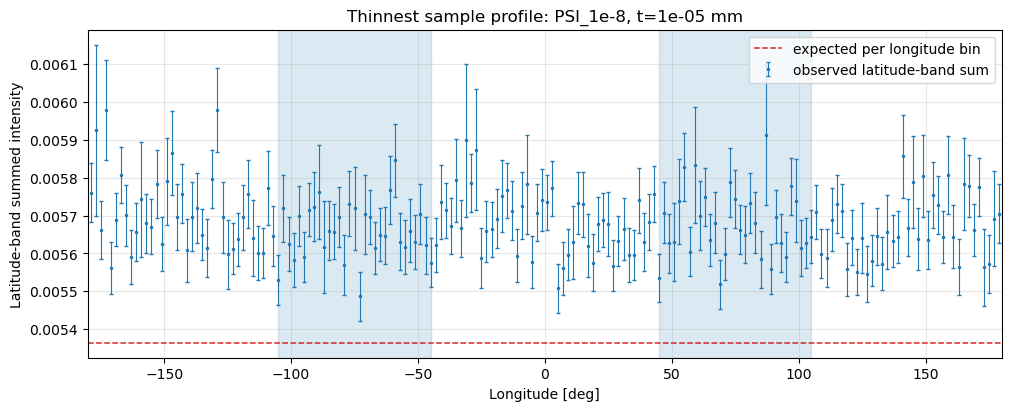

Thinnest run: PSI_1e-8
Flux = 5.99879e+06 +/- 8873.83 n/(s cm^2)
Volume = 1.25664e-05 cm^3
N_sample = 9.07668e+17
Expected window sum = 0.332552
Observed window sum = 0.351471
Observed / expected = 1.05689


In [144]:
# Profile check for the thinnest sample.
thinnest = results.loc[results['thickness_cm'].idxmin()]
records = load_records(thinnest['run_dir'])
spherical = first_available_record(records, spherical_monitor_names)
lat_mask = latitude_mask(spherical)
longitude, profile, profile_error = observed_latitude_band_profile(spherical, lat_mask)
lon_mask = symmetric_window_mask(longitude)
expected = float(thinnest['expected_per_lon_bin'])

fig, ax = plt.subplots(figsize=(10, 4.0), constrained_layout=True)
valid = np.isfinite(profile)
if profile_error is None:
    ax.plot(longitude[valid], profile[valid], '.', markersize=3, label='observed latitude-band sum')
else:
    ax.errorbar(longitude[valid], profile[valid], yerr=profile_error[valid], fmt='.', markersize=3, linewidth=0.8, capsize=1.5, label='observed latitude-band sum')
ax.axhline(expected, color='tab:red', linestyle='--', linewidth=1.1, label='expected per longitude bin')
for center in (window_center_deg, -window_center_deg):
    ax.axvspan(center - window_width_deg / 2.0, center + window_width_deg / 2.0, color='tab:blue', alpha=0.16)
ax.set_xlim(-180, 180)
ax.set_xlabel('Longitude [deg]')
ax.set_ylabel('Latitude-band summed intensity')
ax.set_title(f'Thinnest sample profile: {thinnest["run"]}, t={thinnest["thickness_mm"]:.6g} mm')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()

print(f'Thinnest run: {thinnest["run"]}')
print(f'Flux = {thinnest["flux_cm2_s"]:.6g} +/- {thinnest["flux_err_cm2_s"]:.6g} n/(s cm^2)')
print(f'Volume = {thinnest["volume_cm3"]:.6g} cm^3')
print(f'N_sample = {thinnest["N_sample"]:.6g}')
print(f'Expected window sum = {thinnest["expected_window_sum"]:.6g}')
print(f'Observed window sum = {thinnest["observed_window_sum"]:.6g}')
print(f'Observed / expected = {thinnest["observed_over_expected"]:.6g}')